In [1]:
%load_ext autoreload
%autoreload 2
import sys

ProjDIR = "/home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/" # Change to your project directory
sys.path.insert(1, f'{ProjDIR}/src/')
from CellType_PSY import *
#import scanpy as sc
HGNC, ENSID2Entrez, GeneSymbol2Entrez, Entrez2Symbol = LoadGeneINFO()

try:
    os.chdir(f"{ProjDIR}/notebooks/")
    print(f"Current working directory: {os.getcwd()}")
except FileNotFoundError as e:
    print(f"Error: Could not change directory - {e}")
except Exception as e:
    print(f"Unexpected error: {e}")


import statsmodels.api as sm
from statsmodels.stats.multitest import fdrcorrection, multipletests

Current working directory: /home/jw3514/Work/CellType_Psy/CellTypeBias_VIP/notebooks


In [2]:
import matplotlib.font_manager as fm
font_path = '/usr/share/fonts/truetype/msttcorefonts/Arial.ttf'
fm.fontManager.addfont(font_path)  # Only if you're adding a new font file
fm._load_fontmanager(try_read_cache=False)

# HumanCT IQ Phenotype


In [4]:
HumanCT_Z2_HCT = pd.read_csv("/home/jw3514/Work/CellType_Psy/dat/HumanCTExpressionMats/Human.Cluster.Log2Mean.Z1clip5.Z2.clip3.Dec30.csv", index_col=0)
HumanCT_Z2_HCT.columns = HumanCT_Z2_HCT.columns.astype(int)

In [5]:
Mut_n_IQ = pd.read_csv("../dat/ASD_IQ_Mut.csv")
Mut_n_IQ.columns.values

array(['IID', 'Sex', 'Pheno', 'VarID', 'GeneID', 'HGNC', 'GeneEff',
       'REVEL', 'ExACpLI', 'Entrez', 'IQ'], dtype=object)

In [6]:
Spark_Denovo = pd.read_excel("../dat/41588_2022_1148_MOESM4_ESM.xlsx",
                           skiprows=2, sheet_name="Table S7")
Spark_Denovo = Spark_Denovo[Spark_Denovo[
    "pDenovoWEST_Meta"]!="."]
Spark_Denovo_ExomeWide = Spark_Denovo[Spark_Denovo[
    "pDenovoWEST_Meta"]<=1.3e-6]
Spark_Denovo_ExomeWide.shape

(61, 56)

In [ ]:
top_Genes = Spark_Denovo.head(61)["HGNC"].values
Mut_n_IQ_conf = Mut_n_IQ[Mut_n_IQ["HGNC"].isin(top_Genes)]
Mut_n_IQ_conf.shape

(221, 11)

In [8]:
#### Gene Level
Genes = list(set(Mut_n_IQ_conf["Entrez"].values))
data = []
for g in Genes:
    tmp_df = Mut_n_IQ_conf[Mut_n_IQ_conf["Entrez"]==g]
    avg_IQ = tmp_df["IQ"].mean()
    row = [g, avg_IQ]
    data.append(row)
columns = ["Entrez", "IQ"]
Avg_Gene_IQ_DF = pd.DataFrame(data=data, columns=columns)

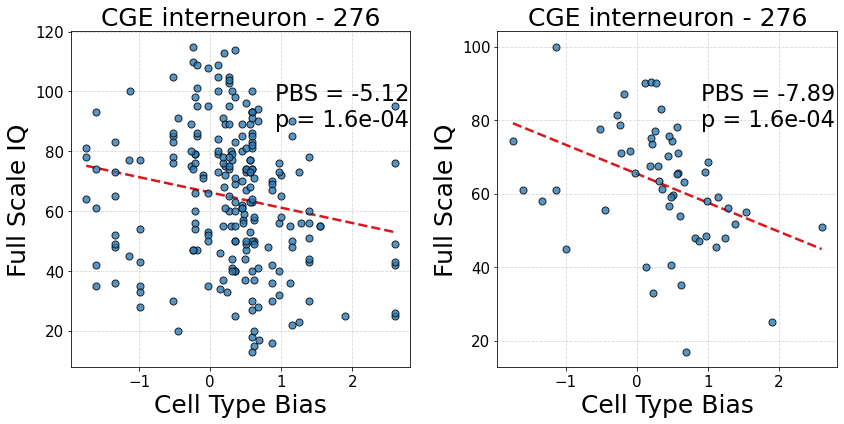

In [10]:
STR = 276
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
Plot_Bias_vs_IQ_HumanCT(STR, Mut_n_IQ_conf, HumanCT_Z2_HCT, ax=ax1)
Plot_Bias_vs_IQ_HumanCT(STR, Avg_Gene_IQ_DF, HumanCT_Z2_HCT, ax=ax2)
plt.tight_layout()
plt.show()

In [13]:
STR = 276
biases, IQs = BiasVsPheno(Avg_Gene_IQ_DF, HumanCT_Z2_HCT , STR, 'XX')
# save biases, IQs to file
np.savetxt("biases.txt", biases)
np.savetxt("IQs.txt", IQs)

# load biases, IQs from file 
biases = np.loadtxt("biases.txt")
IQs = np.loadtxt("IQs.txt")


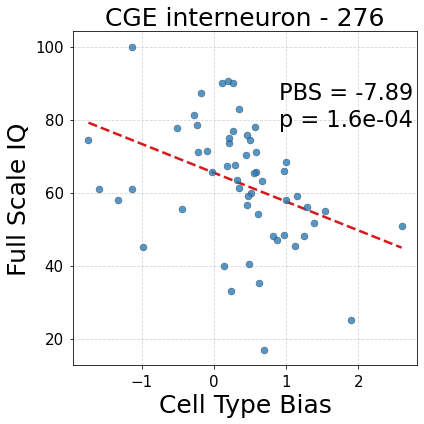

In [14]:
STR = 276
plt.style.use('seaborn-v0_8-paper')
fig, (ax1) = plt.subplots(1, 1, figsize=(6, 6))
#Plot_Bias_vs_IQ_HumanCT(STR, Mut_n_IQ_conf, HCT_Z2_MAT_HCT, ax=ax1)
Plot_Bias_vs_IQ_HumanCT(STR, Avg_Gene_IQ_DF, HumanCT_Z2_HCT, ax=ax1)
plt.tight_layout()
plt.show()

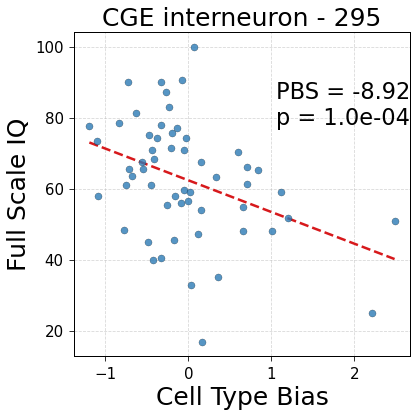

In [31]:
STR = 295
plt.style.use('seaborn-v0_8-paper')
fig, (ax1) = plt.subplots(1, 1, figsize=(6, 6))
#Plot_Bias_vs_IQ_HumanCT(STR, Mut_n_IQ_conf, HCT_Z2_MAT_HCT, ax=ax1)
Plot_Bias_vs_IQ_HumanCT(STR, Avg_Gene_IQ_DF, HumanCT_Z2_HCT, ax=ax1, Pval=0.0001)
plt.tight_layout()
plt.show()

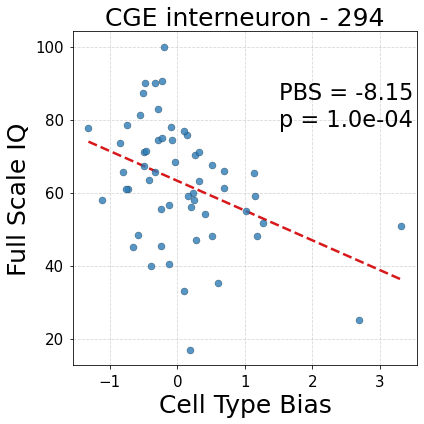

In [16]:
STR = 294
plt.style.use('seaborn-v0_8-paper')
fig, (ax1) = plt.subplots(1, 1, figsize=(6, 6))
#Plot_Bias_vs_IQ_HumanCT(STR, Mut_n_IQ_conf, HumanCT_Z2_HCT, ax=ax1)
Plot_Bias_vs_IQ_HumanCT(STR, Avg_Gene_IQ_DF, HumanCT_Z2_HCT, ax=ax1, Pval=0.0001)
plt.tight_layout()
plt.show()

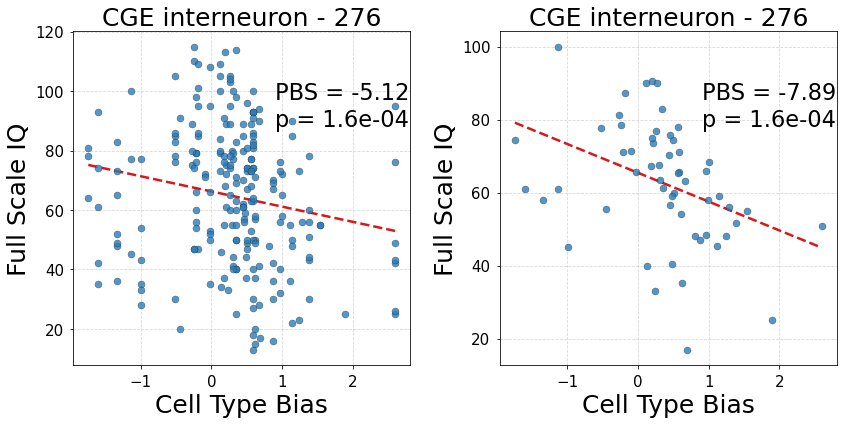

In [17]:
STR = 276
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
Plot_Bias_vs_IQ_HumanCT(STR, Mut_n_IQ_conf, HumanCT_Z2_HCT, ax=ax1)
Plot_Bias_vs_IQ_HumanCT(STR, Avg_Gene_IQ_DF, HumanCT_Z2_HCT, ax=ax2)
plt.tight_layout()
plt.show()

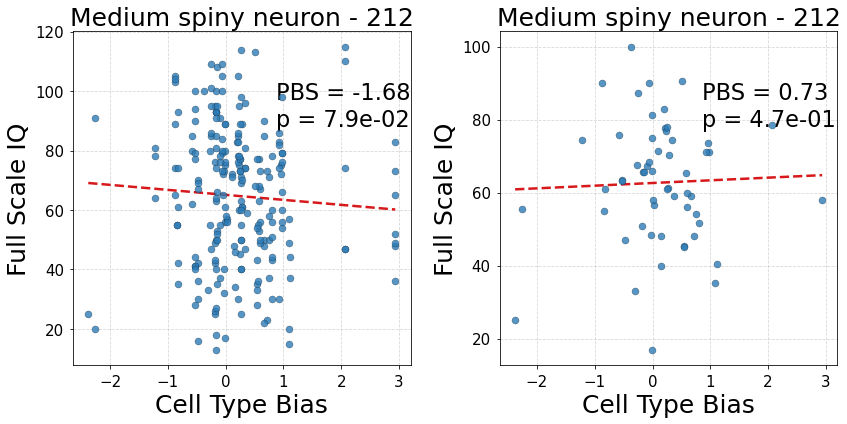

In [18]:
STR = 212
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
Plot_Bias_vs_IQ_HumanCT(STR, Mut_n_IQ_conf, HumanCT_Z2_HCT, ax=ax1)
Plot_Bias_vs_IQ_HumanCT(STR, Avg_Gene_IQ_DF, HumanCT_Z2_HCT, ax=ax2)
plt.tight_layout()
plt.show()

In [19]:
Neuron_idx = Anno[Anno["Supercluster"].isin(Neurons)].index.values

In [20]:
def linear_fit(biases, IQs, alpha=0.05):
    model = sm.OLS(IQs, sm.add_constant(biases))
    results = model.fit()
    
    intercept = results.params[0]
    beta = results.params[1]
    # get CI of beta
    ci = results.conf_int(alpha=alpha)

    ci_low = ci[1][0]
    ci_high = ci[1][1]     
    r_value = results.rsquared
    p_value = results.pvalues[1]
    std_err = results.bse[1]
    rho, p_rho = spearmanr(biases, IQs)
    r, p_r = pearsonr(biases, IQs)
    
    return intercept, beta, ci_low, ci_high, r_value, p_value, std_err, rho, p_rho, r, p_r

def Make_HumanCT_DF(Mut_n_IQ_conf, HCT_Z2_MAT_HCT, output_file, alpha=0.05):
    names, supercluster, spearmanr, spearmanp, pearsonr, pearsonp, beta_values, beta_ci_low, beta_ci_high, intercept_values, r_value_values, p_value_values, std_err_values = [],[],[],[],[],[],[],[],[],[],[],[],[]
    for Idx in HCT_Z2_MAT_HCT.columns.values:
        biases, IQs = BiasVsPheno(Mut_n_IQ_conf, HCT_Z2_MAT_HCT , Idx, 'xx')
        intercept, beta, ci_low, ci_high, r_value, p_value, std_err, rho, p_rho, r, p_r = linear_fit(biases, IQs, alpha=0.05)
        
        names.append("{}".format(Idx))
        supercluster.append(Anno.loc[Idx, "Supercluster"])
        spearmanr.append(rho)
        spearmanp.append(p_rho)
        pearsonr.append(r)
        pearsonp.append(p_r)
        beta_values.append(beta)
        beta_ci_low.append(ci_low)
        beta_ci_high.append(ci_high)
        intercept_values.append(intercept)
        r_value_values.append(r_value)
        p_value_values.append(p_value)
        std_err_values.append(std_err)

    str_res_df = pd.DataFrame(data={"CT":names, "Supercluster":supercluster, "SpearmanR":spearmanr, "SpearmanP":spearmanp, 
                                            "PearsonR":pearsonr, "PearsonP":pearsonp, "beta":beta_values, "CI_low":beta_ci_low, "CI_high":beta_ci_high, "intercept":intercept_values, "r_value":r_value_values, 
                                            "p_value":p_value_values, "std_err":std_err_values})
    str_res_df = str_res_df.sort_values("SpearmanR")
    #str_res_df = ADJ_P(str_res_df)
    str_res_df.to_csv(output_file)
    return str_res_df

In [22]:
HumanCT_res_df_MutL = Make_HumanCT_DF(Mut_n_IQ_conf, HumanCT_Z2_HCT, "../dat/Pheno_Bias_vs_IQ/HumanCT.MutL.csv")
HumanCT_res_df_GeneL = Make_HumanCT_DF(Avg_Gene_IQ_DF, HumanCT_Z2_HCT, "../dat/Pheno_Bias_vs_IQ/HumanCT.GeneL.csv")


In [23]:
HumanCT_res_df_GeneL.sort_values("beta").head(20)

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err
295,295,CGE interneuron,-0.377516,0.004127,-0.383056,0.003569,-8.918079,-14.785443,-3.050715,62.398727,0.146732,0.003569,2.926542
279,279,CGE interneuron,-0.329494,0.013147,-0.371572,0.004808,-8.715744,-14.657160,-2.774327,64.911867,0.138066,0.004808,2.963478
294,294,CGE interneuron,-0.382575,0.003615,-0.398958,0.002321,-8.152247,-13.264305,-3.040189,63.225903,0.159168,0.002321,2.549808
281,281,CGE interneuron,-0.316779,0.017374,-0.315160,0.017987,-8.060151,-14.682130,-1.438172,64.123579,0.099326,0.017987,3.302932
292,292,CGE interneuron,-0.242369,0.071899,-0.323303,0.015079,-7.944026,-14.287827,-1.600224,61.858284,0.104525,0.015079,3.164181
276,276,CGE interneuron,-0.483406,0.000161,-0.383471,0.003530,-7.890700,-13.075557,-2.705843,65.417236,0.147050,0.003530,2.586119
236,236,MGE interneuron,-0.317087,0.017259,-0.327549,0.013729,-7.650455,-13.671306,-1.629604,62.898896,0.107288,0.013729,3.003099
259,259,MGE interneuron,-0.376559,0.004230,-0.346138,0.008971,-7.316326,-12.726645,-1.906007,62.933808,0.119812,0.008971,2.698576
254,254,MGE interneuron,-0.315241,0.017956,-0.303905,0.022782,-7.163512,-13.290344,-1.036680,62.419561,0.092359,0.022782,3.055961
280,280,CGE interneuron,-0.201593,0.136250,-0.286159,0.032512,-6.936334,-13.273007,-0.599661,63.676933,0.081887,0.032512,3.160626


In [60]:
HumanCT_res_df_GeneL.sort_values("beta").head(20)

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err
295,295,CGE interneuron,-0.377516,0.004127,-0.383056,0.003569,-8.918079,-14.785443,-3.050715,62.398727,0.146732,0.003569,2.926542
279,279,CGE interneuron,-0.329494,0.013147,-0.371572,0.004808,-8.715744,-14.657160,-2.774327,64.911867,0.138066,0.004808,2.963478
294,294,CGE interneuron,-0.382575,0.003615,-0.405017,0.001959,-8.509932,-13.751209,-3.268655,63.199902,0.164039,0.001959,2.614261
259,259,MGE interneuron,-0.376559,0.004230,-0.364121,0.005802,-8.431621,-14.315598,-2.547644,62.841492,0.132584,0.005802,2.934829
267,267,LAMP5-LHX6 and Chandelier,-0.474621,0.000219,-0.388152,0.003117,-8.264822,-13.618636,-2.911008,63.306980,0.150662,0.003117,2.670392
281,281,CGE interneuron,-0.316779,0.017374,-0.315160,0.017987,-8.060151,-14.682130,-1.438172,64.123579,0.099326,0.017987,3.302932
292,292,CGE interneuron,-0.242369,0.071899,-0.323303,0.015079,-7.944026,-14.287827,-1.600224,61.858284,0.104525,0.015079,3.164181
276,276,CGE interneuron,-0.483406,0.000161,-0.383471,0.003530,-7.890700,-13.075557,-2.705843,65.417236,0.147050,0.003530,2.586119
286,286,CGE interneuron,-0.310729,0.019761,-0.321221,0.015781,-7.666463,-13.832913,-1.500014,62.714557,0.103183,0.015781,3.075721
236,236,MGE interneuron,-0.317087,0.017259,-0.327638,0.013702,-7.656877,-13.680946,-1.632809,62.898325,0.107347,0.013702,3.004704


In [62]:
HumanCT_res_df_GeneL.sort_values("p_value").head(20)

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err
14,14,Vascular,-0.308496,0.020710,-0.406080,0.001901,-6.436090,-10.387666,-2.484514,60.789444,0.164901,0.001901,1.970979
294,294,CGE interneuron,-0.382575,0.003615,-0.405017,0.001959,-8.509932,-13.751209,-3.268655,63.199902,0.164039,0.001959,2.614261
267,267,LAMP5-LHX6 and Chandelier,-0.474621,0.000219,-0.388152,0.003117,-8.264822,-13.618636,-2.911008,63.306980,0.150662,0.003117,2.670392
276,276,CGE interneuron,-0.483406,0.000161,-0.383471,0.003530,-7.890700,-13.075557,-2.705843,65.417236,0.147050,0.003530,2.586119
295,295,CGE interneuron,-0.377516,0.004127,-0.383056,0.003569,-8.918079,-14.785443,-3.050715,62.398727,0.146732,0.003569,2.926542
279,279,CGE interneuron,-0.329494,0.013147,-0.371572,0.004808,-8.715744,-14.657160,-2.774327,64.911867,0.138066,0.004808,2.963478
364,364,Splatter,0.245753,0.067899,0.366615,0.005451,6.217018,1.912539,10.521497,63.271772,0.134406,0.005451,2.147002
259,259,MGE interneuron,-0.376559,0.004230,-0.364121,0.005802,-8.431621,-14.315598,-2.547644,62.841492,0.132584,0.005802,2.934829
362,362,Splatter,0.148272,0.275456,0.357528,0.006826,6.769745,1.945211,11.594278,63.931468,0.127826,0.006826,2.406396
239,239,MGE interneuron,-0.372048,0.004750,-0.355808,0.007118,-7.246589,-12.439557,-2.053620,62.573185,0.126599,0.007118,2.590165


In [25]:
def SuperClusterBias_BoxPlot_CorrIQ(DF1, flip_axis=True, plot_metric="beta", figsize=(8, 10)):
    # Prepare data
    dat_Z2 = []
    mean_Z2 = []
    for _CT in Neurons:
        tmp = DF1[DF1["Supercluster"] == _CT]
        dat_Z2.append(tmp[plot_metric].values)
        mean_Z2.append(np.mean(tmp[plot_metric].values))
    mean_Z2 = np.array(mean_Z2)

    # Sort data
    if flip_axis:
        sort_idx = np.argsort(mean_Z2)[::-1]
    else:
        sort_idx = np.argsort(mean_Z2)
    show_dat_Z2 = [dat_Z2[x] for x in sort_idx]
    show_CTs = [ALL_CTs[x] for x in sort_idx]

    # Set publication-quality style
    plt.style.use('seaborn-v0_8-paper')
    sns.set_context("paper", font_scale=1.4)
    
    # Create figure
    fig, ax = plt.subplots(dpi=600, figsize=figsize)

    # Define colors and styles
    box_color = '#2E5A88'  # Darker blue
    point_color = '#1f77b4'  # Seaborn blue
    
    # Customize boxplot appearance
    boxprops = dict(linestyle='-', linewidth=1.5, color=box_color, alpha=0.8)
    medianprops = dict(linestyle='-', linewidth=2.5, color='#D62728')  # Red median line
    whiskerprops = dict(color=box_color, linewidth=1.5, alpha=0.8)
    capprops = dict(color=box_color, linewidth=1.5)
    flierprops = dict(marker='', color=box_color, alpha=0)  # Hide outliers

    # Draw boxplot
    bp = ax.boxplot(show_dat_Z2, labels=show_CTs, vert=False, patch_artist=True,
                    boxprops=boxprops, medianprops=medianprops,
                    whiskerprops=whiskerprops, capprops=capprops, flierprops=flierprops)
    
    # Fill boxes with lighter color
    for patch in bp['boxes']:
        patch.set_facecolor('#A8C8E4')  # Light blue
        patch.set_alpha(0.3)

    # Add individual points with jitter
    for i in range(len(show_dat_Z2)):
        y = np.random.normal(i + 1, 0.08, size=len(show_dat_Z2[i]))
        ax.scatter(show_dat_Z2[i], y, s=20, color=point_color, alpha=0.4, 
                  edgecolor='none', zorder=2)

    # Customize grid
    ax.grid(True, axis='x', linestyle='--', alpha=0.3, color='gray')
    ax.grid(False, axis='y')

    # Labels and title
    if plot_metric == "beta":
        ax.set_xlabel("PBS", fontsize=20, fontweight='normal')
    elif plot_metric == "SpearmanR":
        ax.set_xlabel("Spearman Correlation", fontsize=20, fontweight='normal')
    ax.set_ylabel("Superclusters", fontsize=20, fontweight='normal')

    # Customize axis appearance
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Adjust tick parameters
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='y', length=0)  # Remove y-axis ticks
    
    # Flip axis if needed
    if flip_axis:
        ax.invert_xaxis()
    
    if plot_metric == "beta":
        ax.set_xlim(7.5, -10)

    # Add zero line
    ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

    plt.tight_layout()
    plt.show()

def mapsize(x, min_size, max_size):
    return 5 + 50 * (x - min_size) / (max_size - min_size)

def plot_mutation_bias(df, beta_column, size_column='n_cells'):
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax1 = plt.subplots(figsize=(11, 11), dpi=600)

    if beta_column not in df.columns:
        print(f"'{beta_column}' column not found. Available columns:", df.columns)
        return

    # Prepare data
    median_bias = df.groupby("Subclass_idx")[beta_column].median().sort_values()
    sorted_superclusters = median_bias.index
    x_categorical = pd.Categorical(df['Subclass_idx'], categories=sorted_superclusters, ordered=True)
    x_numeric = x_categorical.codes

    # Enhanced boxplot
    sns.boxplot(x=x_numeric, y=beta_column, data=df,
                order=range(len(sorted_superclusters)), 
                color='white', fliersize=0, ax=ax1, zorder=0,
                boxprops={'alpha': 0.7, 'linewidth': 1.5},
                whiskerprops={'linewidth': 1.5},
                capprops={'linewidth': 1.5},
                medianprops={'color': '#D62728', 'linewidth': 2})

    # Add points with size proportional to cell count
    min_size, max_size = df[size_column].min(), df[size_column].max()
    for i, idx in enumerate(sorted_superclusters):
        subset = df[df["Subclass_idx"] == idx]
        color = '#2171B5' if 'Gaba' in subset['Subclass'].iloc[0] else '#CB181D'  # Darker colors
        jittered_x = np.random.normal(i, 0.1, size=len(subset))
        ax1.scatter(jittered_x, subset[beta_column],
                   s=mapsize(subset[size_column], min_size, max_size),
                   color=color, alpha=0.6, edgecolors='none', zorder=10)

    # Enhance plot appearance
    ax1.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax1.grid(True, linestyle='--', alpha=0.3)
    ax1.set_ylabel(f'Mutation Bias - IQ {beta_column}', fontsize=14, fontweight='normal')
    ax1.tick_params(axis='both', which='major', labelsize=12)
    
    # Add weighted mean line
    weighted_mean_beta = (df[beta_column] * df[size_column]).sum() / df[size_column].sum()
    ax1.axhline(weighted_mean_beta, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
    ax1.text(0.90, weighted_mean_beta * 1.1, 'Cell Mean',
             transform=ax1.get_yaxis_transform(), color='gray', 
             fontsize=12, fontweight='bold', ha='left', va='center')

    # Create legend
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', label='Inhibitory',
                   markerfacecolor='#2171B5', markersize=10),
        plt.Line2D([0], [0], marker='o', color='w', label='Excitatory',
                   markerfacecolor='#CB181D', markersize=10)
    ]
    ax1.legend(handles=legend_elements, loc='upper right', frameon=True, 
               framealpha=0.9, edgecolor='none')

    ax1.invert_yaxis()

    plt.tight_layout()
    plt.show()


In [26]:
print(np.mean(HumanCT_res_df_GeneL[HumanCT_res_df_GeneL["Supercluster"]=="CGE interneuron"]["beta"]))
print(np.mean(HumanCT_res_df_GeneL[HumanCT_res_df_GeneL["Supercluster"]=="LAMP5-LHX6 and Chandelier"]["beta"]))
print(np.mean(HumanCT_res_df_GeneL[HumanCT_res_df_GeneL["Supercluster"]=="MGE interneuron"]["beta"]))

-6.125795169655515
-4.33513233474064
-5.557618634534513


/tmp/ipykernel_1084052/2720857543.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(show_dat_Z2, labels=show_CTs, vert=False, patch_artist=True,


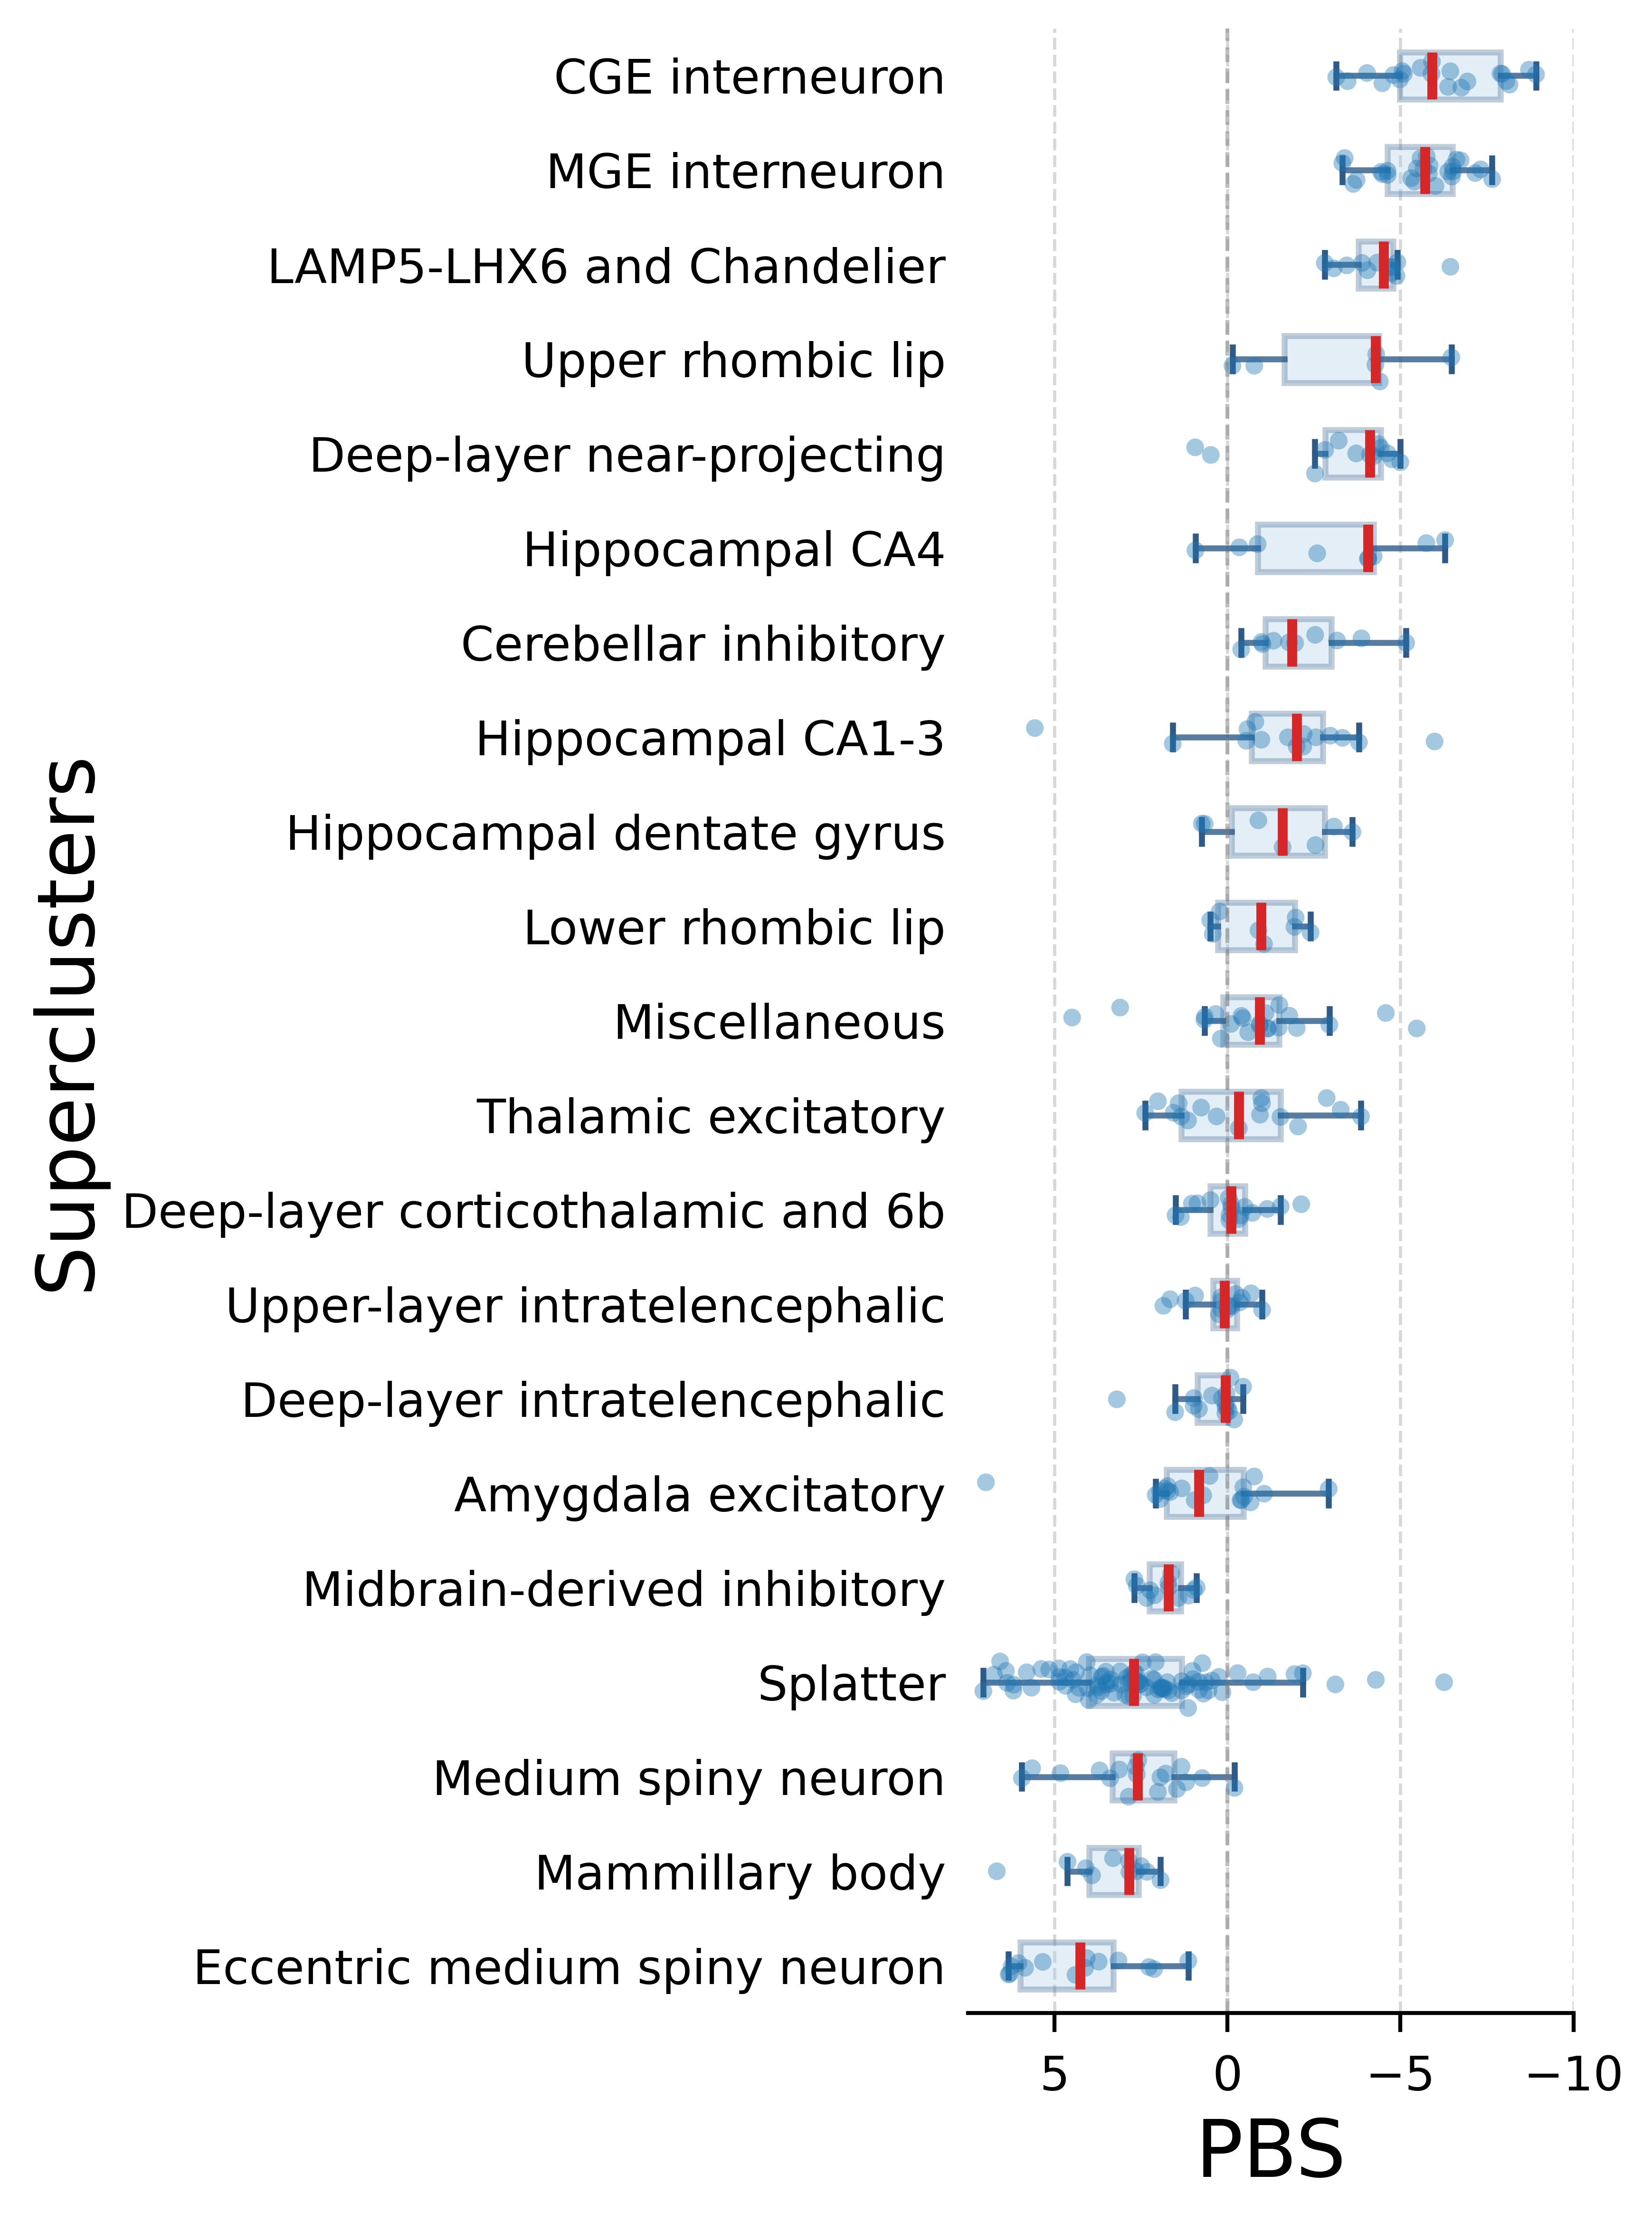

In [27]:
SuperClusterBias_BoxPlot_CorrIQ(HumanCT_res_df_GeneL, flip_axis=True, figsize=(6, 8))

### Mut IQ permutation

In [119]:
#Perm_DIR = "/home/jw3514/Work/CellType_Psy/dat/Pheno_Bias_vs_IQ/IQ_Permuts/HumanCT_Feb25/ALL/"
Perm_DIR = "/home/jw3514/Work/CellType_Psy/dat/Pheno_Bias_vs_IQ/IQ_Permuts/HumanCT_Feb25_Seed42/ALL/"
Perm_DFs = []
for df in os.listdir(Perm_DIR):
    df = pd.read_csv(f"{Perm_DIR}/{df}", index_col=0)
    df.index = df.index.astype(int)
    Perm_DFs.append(df)
print(len(Perm_DFs))


10000


In [120]:
def plot_null_distributions(HumanCT_res_df_GeneL, Perm_DFs, CT=276, plot=False):
    """
    Plot null distributions of Rho and Beta values compared to observed values for a given cell type.
    
    Parameters:
    -----------
    HumanCT_res_df_GeneL : pandas DataFrame
        DataFrame containing observed results
    Perm_DFs : list
        List of DataFrames containing permutation results
    CT : int
        Cell type ID to analyze (default: 276)
    """
    Obs_Rho = HumanCT_res_df_GeneL.loc[CT, "SpearmanR"]
    Obs_Beta = HumanCT_res_df_GeneL.loc[CT, "beta"]
    
    Null_Rho = []
    Null_Beta = []
    for df in Perm_DFs:
        Null_Rho.append(df.loc[CT, "SpearmanR"])
        Null_Beta.append(df.loc[CT, "beta"])
    Null_Rho = np.array(Null_Rho)
    Null_Beta = np.array(Null_Beta)
    # Calculate p-values
    p_rho = (Null_Rho <= Obs_Rho).mean()
    p_beta = (Null_Beta <= Obs_Beta).mean()
    
    if plot:
        # Create plots comparing observed values to null distributions
        plt.figure(figsize=(10,5))

        # Plot Rho distribution and observed value
        plt.subplot(121)
        plt.hist(Null_Rho, bins=20, alpha=0.5)
        plt.axvline(x=Obs_Rho, color='red', linestyle='--', label='Observed')
        plt.xlabel('Rho')
        plt.ylabel('Count')
        plt.text(0.60, 0.60, f'p_rho = {p_rho:.2e}', transform=plt.gca().transAxes, fontsize=12, ha='right', va='top')
        plt.title('Rho: Null Distribution vs Observed')
        plt.legend()

        # Plot Beta distribution and observed value  
        plt.subplot(122)
        plt.hist(Null_Beta, bins=20, alpha=0.5)
        plt.axvline(x=Obs_Beta, color='red', linestyle='--', label='Observed')
        plt.xlabel('Beta')
        plt.ylabel('Count')
        plt.title('Beta: Null Distribution vs Observed')
        plt.legend()
    # annotate p-values

        plt.text(0.60, 0.60, f'p_beta = {p_beta:.2e}', transform=plt.gca().transAxes, fontsize=12, ha='right', va='top')
        plt.tight_layout()
        plt.show()
    
    return p_rho, p_beta

def plot_null_suptercluster_distributions(ClusterIdx, HumanCT_res_df_GeneL, Perm_DFs, plot=False):

    Obs_Rho = HumanCT_res_df_GeneL.loc[ClusterIdx, "SpearmanR"].mean()
    Obs_Beta = HumanCT_res_df_GeneL.loc[ClusterIdx, "beta"].mean()
    

    Null_Rho = []
    Null_Beta = []
    for df in Perm_DFs:
        Null_Rho.append(df.loc[ClusterIdx, "SpearmanR"].mean())
        Null_Beta.append(df.loc[ClusterIdx, "beta"].mean())
    Null_Rho = np.array(Null_Rho)
    Null_Beta = np.array(Null_Beta)
    # Calculate p-values
    p_rho = (Null_Rho <= Obs_Rho).mean()
    p_beta = (Null_Beta <= Obs_Beta).mean()

    
    if plot:
        # Create plots comparing observed values to null distributions
        plt.figure(figsize=(10,5))

        # Plot Rho distribution and observed value
        plt.subplot(121)
        plt.hist(Null_Rho, bins=20, alpha=0.5)
        plt.axvline(x=Obs_Rho, color='red', linestyle='--', label='Observed')
        plt.xlabel('Rho')
        plt.ylabel('Count')
        plt.text(0.60, 0.60, f'p_rho = {p_rho:.2e}', transform=plt.gca().transAxes, fontsize=12, ha='right', va='top')
        plt.title('Rho: Null Distribution vs Observed')
        plt.legend()

        # Plot Beta distribution and observed value  
        plt.subplot(122)
        plt.hist(Null_Beta, bins=20, alpha=0.5)
        plt.axvline(x=Obs_Beta, color='red', linestyle='--', label='Observed')
        plt.xlabel('Beta')
        plt.ylabel('Count')
        plt.title('Beta: Null Distribution vs Observed')
        plt.legend()
    # annotate p-values

        plt.text(0.60, 0.60, f'p_beta = {p_beta:.2e}', transform=plt.gca().transAxes, fontsize=12, ha='right', va='top')
        plt.tight_layout()
        plt.show()
    
    return p_rho, p_beta

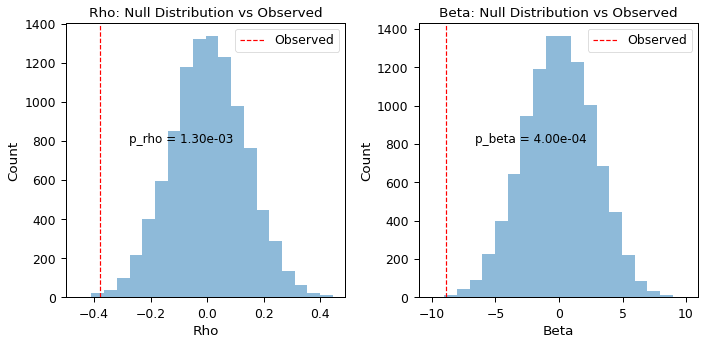

(0.0013, 0.0004)

In [121]:
plot_null_distributions(HumanCT_res_df_GeneL, Perm_DFs, CT=295, plot=True)

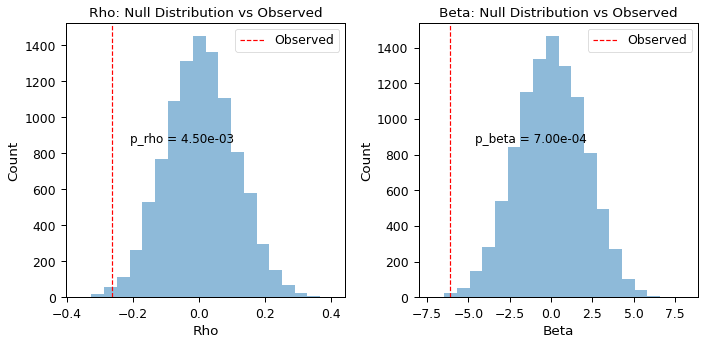

In [122]:
Supercluster = "CGE interneuron"
ClusterIdx = Anno[Anno["Supercluster"]==Supercluster].index.values

p_rho, p_beta = plot_null_suptercluster_distributions(ClusterIdx, HumanCT_res_df_GeneL, Perm_DFs, plot=True)

In [144]:
#Supercluster = "CGE interneuron"
# Create DataFrame to store results
results_df = pd.DataFrame(columns=['Supercluster', 'p_rho', 'p_beta'])

for Supercluster in Neurons:
    ClusterIdx = Anno[Anno["Supercluster"]==Supercluster].index.values
    p_rho, p_beta = plot_null_suptercluster_distributions(ClusterIdx, HumanCT_res_df_GeneL, Perm_DFs, plot=False)
    
    # Add results to DataFrame
    results_df = results_df.append({
        'Supercluster': Supercluster,
        "mean_PBS": HumanCT_res_df_GeneL.loc[ClusterIdx, "beta"].mean(),
        'p_rho': p_rho,
        'p_beta': p_beta
    }, ignore_index=True)

/tmp/ipykernel_1084052/886986433.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({
/tmp/ipykernel_1084052/886986433.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({
/tmp/ipykernel_1084052/886986433.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({
/tmp/ipykernel_1084052/886986433.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df = results_df.append({
/tmp/ipykernel_1084052/886986433.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat inst

In [145]:
# Add FDR corrected p-values
results_df['p_rho_FDR'] = multipletests(results_df['p_rho'], method='fdr_bh')[1]
results_df['p_beta_FDR'] = multipletests(results_df['p_beta'], method='fdr_bh')[1]

results_df.sort_values("p_beta")

,Supercluster,p_rho,p_beta,mean_PBS,p_rho_FDR,p_beta_FDR
1,CGE interneuron,0.0045,0.0007,-6.125795,0.047250,0.014700
10,LAMP5-LHX6 and Chandelier,0.0025,0.0029,-4.335132,0.047250,0.030450
12,MGE interneuron,0.0165,0.0044,-5.557619,0.115500,0.030800
2,Cerebellar inhibitory,0.1832,0.0450,-2.219126,0.542967,0.189840
19,Upper rhombic lip,0.0523,0.0452,-3.394484,0.274575,0.189840
5,Deep-layer near-projecting,0.1987,0.1093,-3.260689,0.542967,0.344400
8,Hippocampal CA4,0.2186,0.1148,-3.030513,0.542967,0.344400
7,Hippocampal CA1-3,0.4004,0.1857,-1.501789,0.646800,0.487463
16,Miscellaneous,0.2259,0.2167,-0.778925,0.542967,0.505633
9,Hippocampal dentate gyrus,0.2677,0.2547,-1.473886,0.562170,0.534870


In [125]:
for i, row in HumanCT_res_df_GeneL.iterrows():
    ct = int(row["CT"])
    p_rho, p_beta = plot_null_distributions(HumanCT_res_df_GeneL, Perm_DFs, CT=ct, plot=False)
    HumanCT_res_df_GeneL.loc[i, "p_rho_perm"] = p_rho
    HumanCT_res_df_GeneL.loc[i, "p_beta_perm"] = p_beta
#HumanCT_res_df_GeneL.sort_values("p_beta_FDR")

In [126]:
HumanCT_res_df_GeneL_neuron = HumanCT_res_df_GeneL[HumanCT_res_df_GeneL["Supercluster"].isin(Neurons)]

In [127]:
HumanCT_res_df_GeneL = HumanCT_res_df_GeneL.sort_values("p_beta_perm")
HumanCT_res_df_GeneL_neuron = HumanCT_res_df_GeneL_neuron.sort_values("p_beta_perm")
print(HumanCT_res_df_GeneL.shape, HumanCT_res_df_GeneL_neuron.shape)


(461, 17) (382, 17)


In [128]:
HumanCT_res_df_GeneL['p_rho_perm_FDR'] = multipletests(HumanCT_res_df_GeneL['p_rho_perm'], method='fdr_bh')[1]
HumanCT_res_df_GeneL['p_beta_perm_FDR'] = multipletests(HumanCT_res_df_GeneL['p_beta_perm'], method='fdr_bh')[1]

HumanCT_res_df_GeneL_neuron['p_rho_perm_FDR'] = multipletests(HumanCT_res_df_GeneL_neuron['p_rho_perm'], method='fdr_bh')[1]
HumanCT_res_df_GeneL_neuron['p_beta_perm_FDR'] = multipletests(HumanCT_res_df_GeneL_neuron['p_beta_perm'], method='fdr_bh')[1]

In [129]:
HumanCT_res_df_GeneL_neuron.head(10)

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err,p_rho_perm,p_beta_perm,p_rho_perm_FDR,p_beta_perm_FDR
294,294,CGE interneuron,-0.382575,0.003615,-0.398958,0.002321,-8.152247,-13.264305,-3.040189,63.225903,0.159168,0.002321,2.549808,0.0012,0.0002,0.080220,0.038200
276,276,CGE interneuron,-0.483406,0.000161,-0.383471,0.003530,-7.890700,-13.075557,-2.705843,65.417236,0.147050,0.003530,2.586119,0.0000,0.0002,0.000000,0.038200
259,259,MGE interneuron,-0.376559,0.004230,-0.346138,0.008971,-7.316326,-12.726645,-1.906007,62.933808,0.119812,0.008971,2.698576,0.0017,0.0003,0.080220,0.038200
295,295,CGE interneuron,-0.377516,0.004127,-0.383056,0.003569,-8.918079,-14.785443,-3.050715,62.398727,0.146732,0.003569,2.926542,0.0013,0.0004,0.080220,0.038200
267,267,LAMP5-LHX6 and Chandelier,-0.474621,0.000219,-0.354777,0.007298,-6.443808,-11.076857,-1.810759,63.368853,0.125867,0.007298,2.310887,0.0001,0.0006,0.012733,0.045840
279,279,CGE interneuron,-0.329494,0.013147,-0.371572,0.004808,-8.715744,-14.657160,-2.774327,64.911867,0.138066,0.004808,2.963478,0.0054,0.0009,0.150890,0.049954
236,236,MGE interneuron,-0.317087,0.017259,-0.327549,0.013729,-7.650455,-13.671306,-1.629604,62.898896,0.107288,0.013729,3.003099,0.0079,0.0012,0.150890,0.049954
266,266,LAMP5-LHX6 and Chandelier,-0.454216,0.000438,-0.292665,0.028605,-4.327418,-8.184906,-0.469930,62.649056,0.085653,0.028605,1.924050,0.0001,0.0014,0.012733,0.049954
269,269,LAMP5-LHX6 and Chandelier,-0.382336,0.003638,-0.300439,0.024460,-4.909546,-9.161945,-0.657148,63.373402,0.090264,0.024460,2.121025,0.0015,0.0014,0.080220,0.049954
268,268,LAMP5-LHX6 and Chandelier,-0.408791,0.001760,-0.303784,0.022839,-4.883216,-9.061587,-0.704845,63.385239,0.092285,0.022839,2.084101,0.0007,0.0015,0.066850,0.049954


In [130]:
HumanCT_res_df_GeneL = HumanCT_res_df_GeneL.sort_values("beta")

In [131]:
HumanCT_res_df_GeneL.head(10)

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err,p_rho_perm,p_beta_perm,p_rho_perm_FDR,p_beta_perm_FDR
295,295,CGE interneuron,-0.377516,0.004127,-0.383056,0.003569,-8.918079,-14.785443,-3.050715,62.398727,0.146732,0.003569,2.926542,0.0013,0.0004,0.096810,0.036880
279,279,CGE interneuron,-0.329494,0.013147,-0.371572,0.004808,-8.715744,-14.657160,-2.774327,64.911867,0.138066,0.004808,2.963478,0.0054,0.0009,0.182095,0.052247
294,294,CGE interneuron,-0.382575,0.003615,-0.398958,0.002321,-8.152247,-13.264305,-3.040189,63.225903,0.159168,0.002321,2.549808,0.0012,0.0002,0.096810,0.034575
281,281,CGE interneuron,-0.316779,0.017374,-0.315160,0.017987,-8.060151,-14.682130,-1.438172,64.123579,0.099326,0.017987,3.302932,0.0070,0.0043,0.182095,0.082596
292,292,CGE interneuron,-0.242369,0.071899,-0.323303,0.015079,-7.944026,-14.287827,-1.600224,61.858284,0.104525,0.015079,3.164181,0.0303,0.0040,0.367587,0.080174
276,276,CGE interneuron,-0.483406,0.000161,-0.383471,0.003530,-7.890700,-13.075557,-2.705843,65.417236,0.147050,0.003530,2.586119,0.0000,0.0002,0.000000,0.034575
236,236,MGE interneuron,-0.317087,0.017259,-0.327549,0.013729,-7.650455,-13.671306,-1.629604,62.898896,0.107288,0.013729,3.003099,0.0079,0.0012,0.182095,0.052247
259,259,MGE interneuron,-0.376559,0.004230,-0.346138,0.008971,-7.316326,-12.726645,-1.906007,62.933808,0.119812,0.008971,2.698576,0.0017,0.0003,0.096810,0.034575
254,254,MGE interneuron,-0.315241,0.017956,-0.303905,0.022782,-7.163512,-13.290344,-1.036680,62.419561,0.092359,0.022782,3.055961,0.0087,0.0063,0.190986,0.098347
280,280,CGE interneuron,-0.201593,0.136250,-0.286159,0.032512,-6.936334,-13.273007,-0.599661,63.676933,0.081887,0.032512,3.160626,0.0516,0.0064,0.506119,0.098347


In [146]:
HumanCT_res_df_GeneL.to_csv("../dat/Pheno_Bias_vs_IQ/HumanCT.GeneL.cluster.Feb25.csv")
results_df.to_csv("../dat/Pheno_Bias_vs_IQ/HumanCT.GeneL.Supercluster.Feb25.csv")

In [148]:
HumanCT_res_df_GeneL.head(2)

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err,p_rho_perm,p_beta_perm,p_rho_perm_FDR,p_beta_perm_FDR
295,295,CGE interneuron,-0.377516,0.004127,-0.383056,0.003569,-8.918079,-14.785443,-3.050715,62.398727,0.146732,0.003569,2.926542,0.0013,0.0004,0.096810,0.036880
279,279,CGE interneuron,-0.329494,0.013147,-0.371572,0.004808,-8.715744,-14.657160,-2.774327,64.911867,0.138066,0.004808,2.963478,0.0054,0.0009,0.182095,0.052247


#### Test VIP+ and VIP-

In [147]:
CGE_VIP_Pos_list = np.loadtxt("../dat/Other/CGE_VIP_Pos.txt", dtype=int)
CGE_VIP_Neg_list = np.loadtxt("../dat/Other/CGE_VIP_Neg.txt", dtype=int)

In [149]:
VIP_pos_meanPBS = HumanCT_res_df_GeneL[HumanCT_res_df_GeneL.index.isin(CGE_VIP_Pos_list)]["beta"].mean()
VIP_neg_meanPBS = HumanCT_res_df_GeneL[HumanCT_res_df_GeneL.index.isin(CGE_VIP_Neg_list)]["beta"].mean()
DIFF_obs = VIP_pos_meanPBS - VIP_neg_meanPBS
print(VIP_pos_meanPBS, VIP_neg_meanPBS, VIP_pos_meanPBS - VIP_neg_meanPBS)

-6.779832002781753 -4.817721503403035 -1.962110499378718


In [156]:
null_diffs = []
for i in range(10000):
    tmpDF = Perm_DFs[i]
    tmp_VIP_pos_meanPBS = tmpDF[tmpDF.index.isin(CGE_VIP_Pos_list)]["beta"].mean()
    tmp_VIP_neg_meanPBS = tmpDF[tmpDF.index.isin(CGE_VIP_Neg_list)]["beta"].mean()
    null_diffs.append(tmp_VIP_pos_meanPBS - tmp_VIP_neg_meanPBS)
null_diffs = np.array(null_diffs)

Observed difference: -1.962
P-value: 6.000e-02


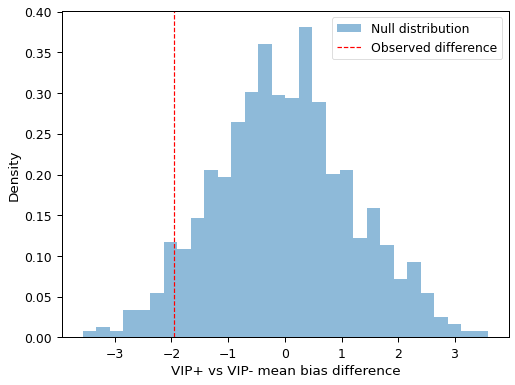

In [155]:
# Plot observed difference vs null distribution
plt.figure(figsize=(8,6))
plt.hist(null_diffs, bins=30, density=True, alpha=0.5, label='Null distribution')
plt.axvline(DIFF_obs, color='red', linestyle='dashed', label='Observed difference')
plt.xlabel('VIP+ vs VIP- mean bias difference')
plt.ylabel('Density')
plt.legend()

#compute 1-sided p-value
pval = np.mean(null_diffs <= DIFF_obs)
print(f"Observed difference: {DIFF_obs:.3f}")
print(f"P-value: {pval:.3e}")

### LGD vs Dmis

In [132]:
Mut_n_IQ_conf_LGD = Mut_n_IQ_conf[Mut_n_IQ_conf["GeneEff"]!="missense"]
Mut_n_IQ_conf_Dmis = Mut_n_IQ_conf[Mut_n_IQ_conf["GeneEff"]=="missense"]
print(Mut_n_IQ_conf.shape, Mut_n_IQ_conf_LGD.shape, Mut_n_IQ_conf_Dmis.shape)

(221, 11) (149, 11) (72, 11)


In [133]:
# Calculate gene level for Mut_n_IQ_conf
Genes_LGD = list(set(Mut_n_IQ_conf_LGD["Entrez"].values))
data_LGD = []
for g in Genes_LGD:
    tmp_df = Mut_n_IQ_conf_LGD[Mut_n_IQ_conf_LGD["Entrez"]==g]
    avg_IQ = tmp_df["IQ"].mean()
    row = [g, avg_IQ]
    data_LGD.append(row)
columns = ["Entrez", "IQ"]
Avg_Gene_IQ_DF_LGD = pd.DataFrame(data=data_LGD, columns=columns)

# Calculate gene level for Mut_n_IQ_Dmis
Genes_Dmis = list(set(Mut_n_IQ_conf_Dmis["Entrez"].values))
data_Dmis = []
for g in Genes_Dmis:
    tmp_df = Mut_n_IQ_conf_Dmis[Mut_n_IQ_conf_Dmis["Entrez"]==g]
    avg_IQ = tmp_df["IQ"].mean()
    row = [g, avg_IQ]
    data_Dmis.append(row)
Avg_Gene_IQ_DF_Dmis = pd.DataFrame(data=data_Dmis, columns=columns)



In [134]:
HumanCT_res_df_GeneL_LGD = Make_HumanCT_DF(Avg_Gene_IQ_DF_LGD, HumanCT_Z2_HCT, "../dat/Pheno_Bias_vs_IQ/HumanCT.GeneL.LGD.csv")
HumanCT_res_df_GeneL_Dmis = Make_HumanCT_DF(Avg_Gene_IQ_DF_Dmis, HumanCT_Z2_HCT, "../dat/Pheno_Bias_vs_IQ/HumanCT.GeneL.Dmis.csv")

/tmp/ipykernel_1084052/2720857543.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(show_dat_Z2, labels=show_CTs, vert=False, patch_artist=True,


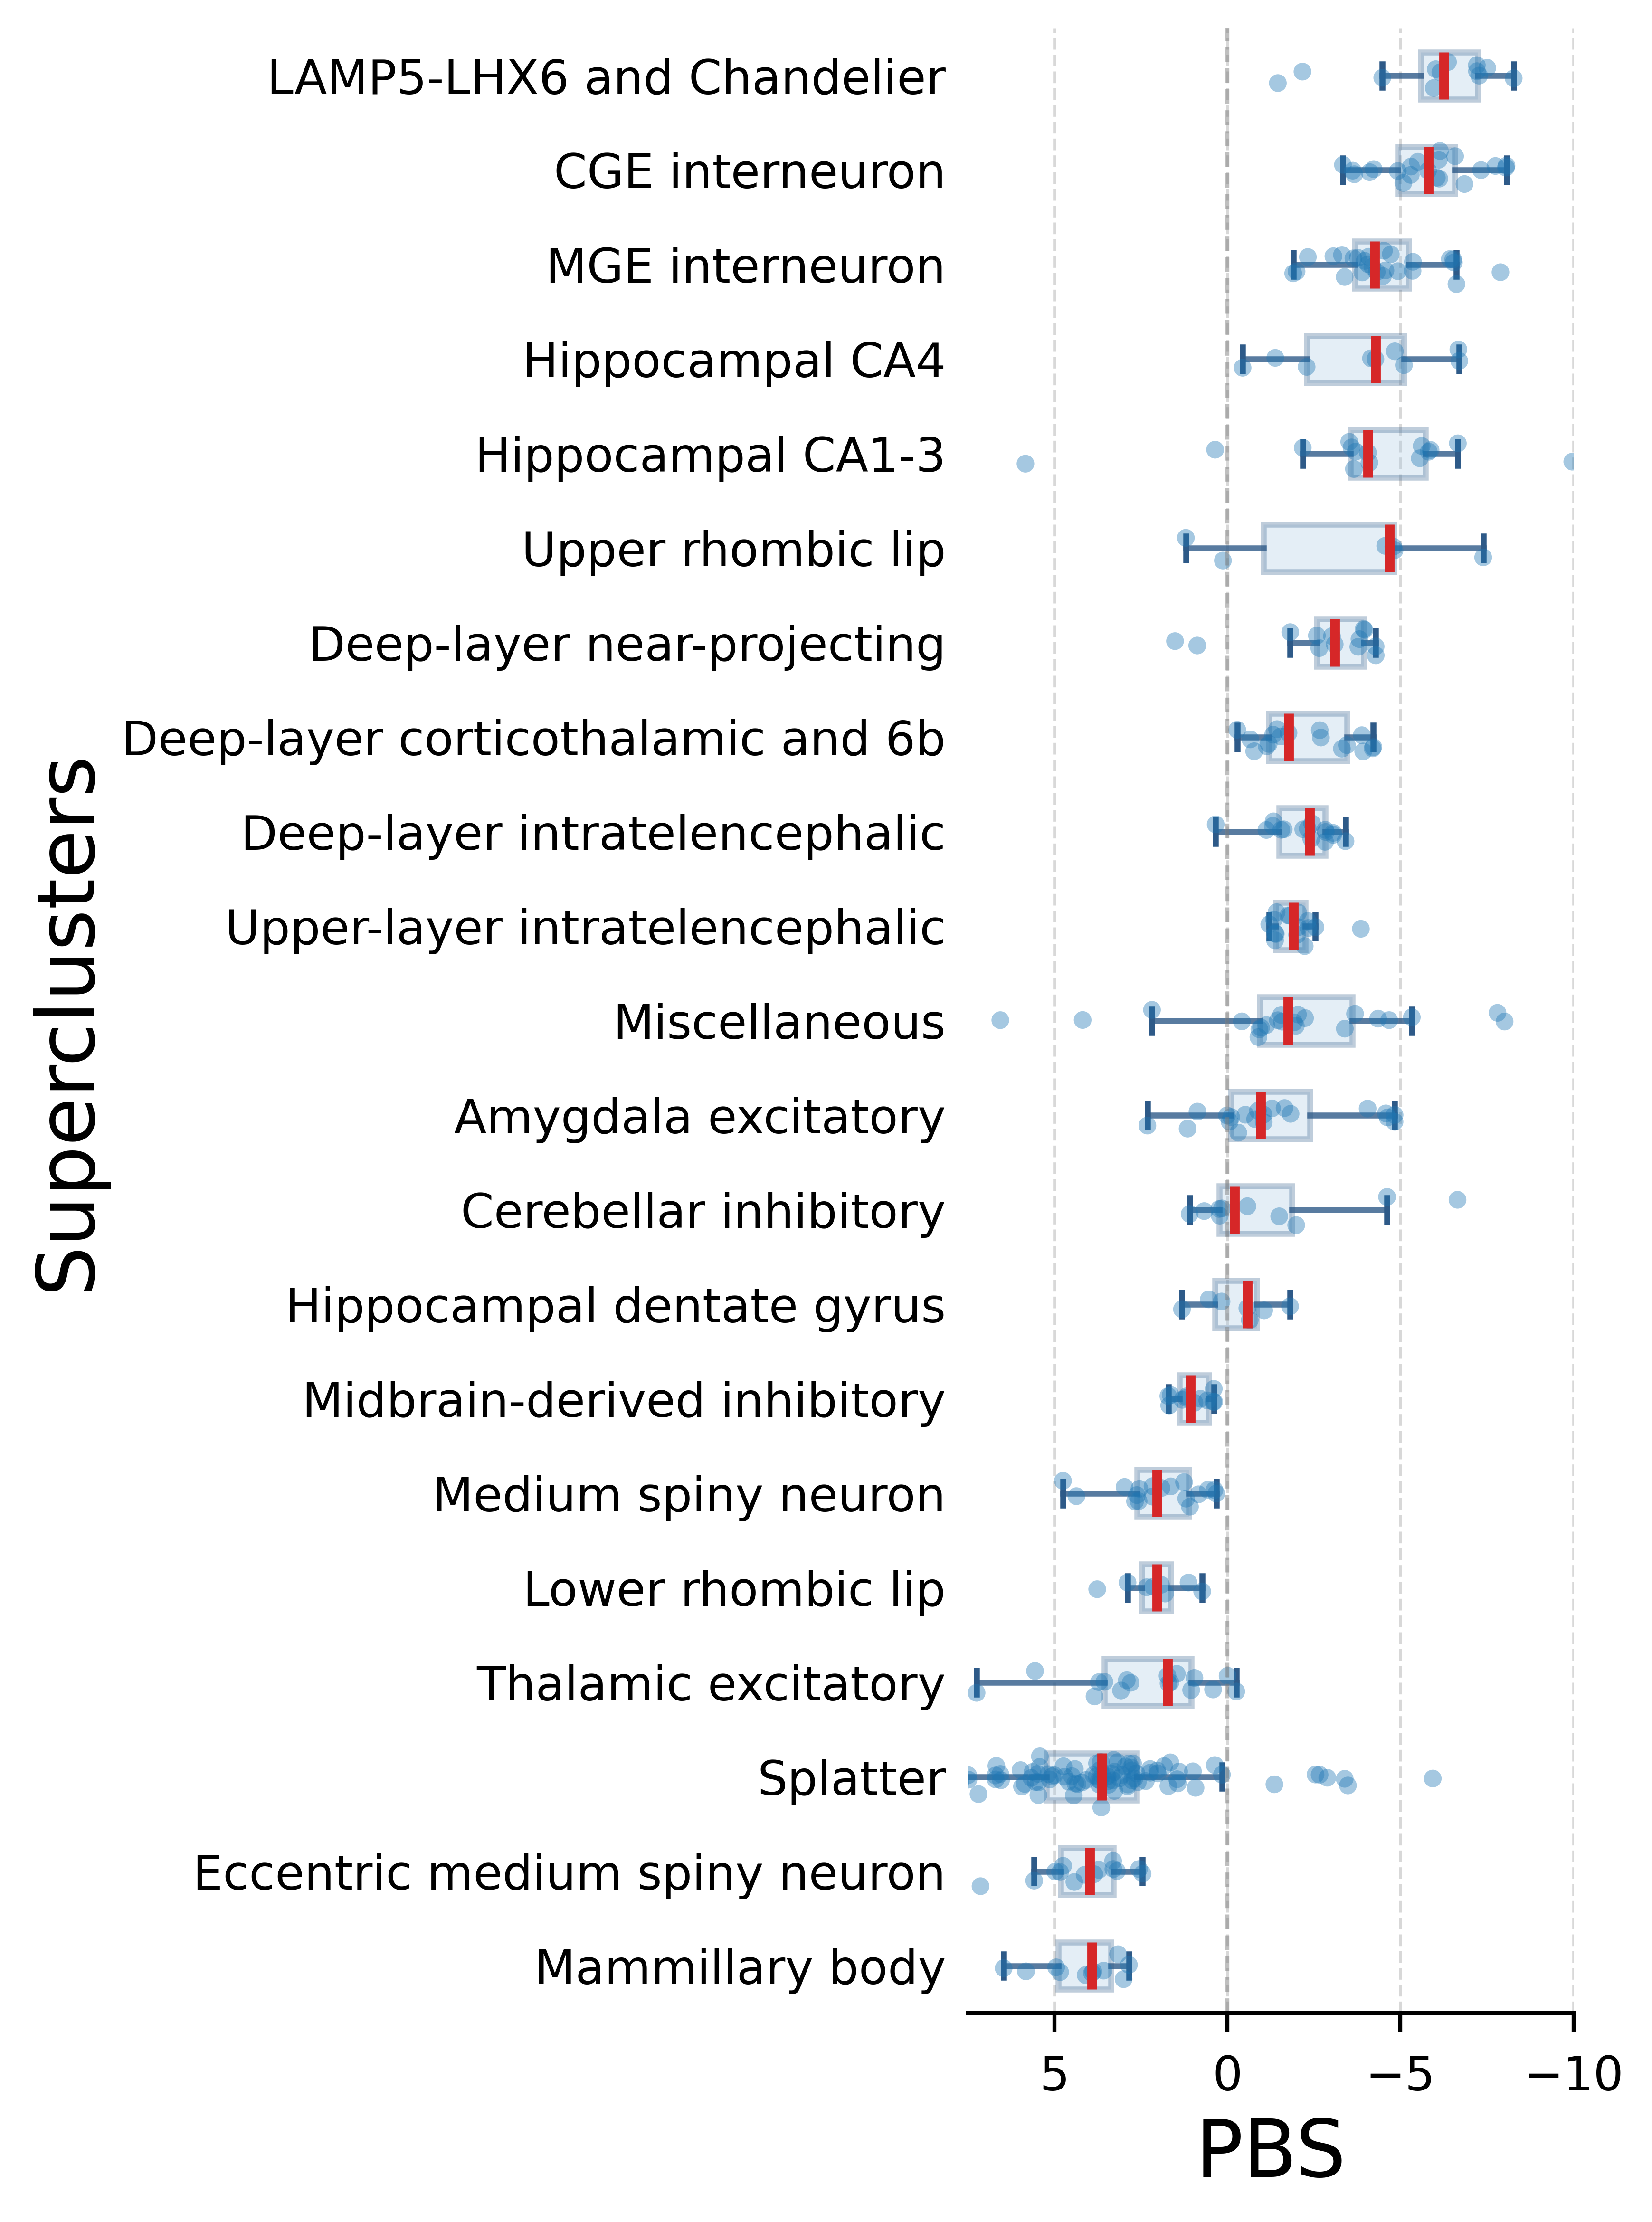

In [135]:
SuperClusterBias_BoxPlot_CorrIQ(HumanCT_res_df_GeneL_LGD, flip_axis=True, figsize=(6, 8))

/tmp/ipykernel_1084052/2720857543.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(show_dat_Z2, labels=show_CTs, vert=False, patch_artist=True,


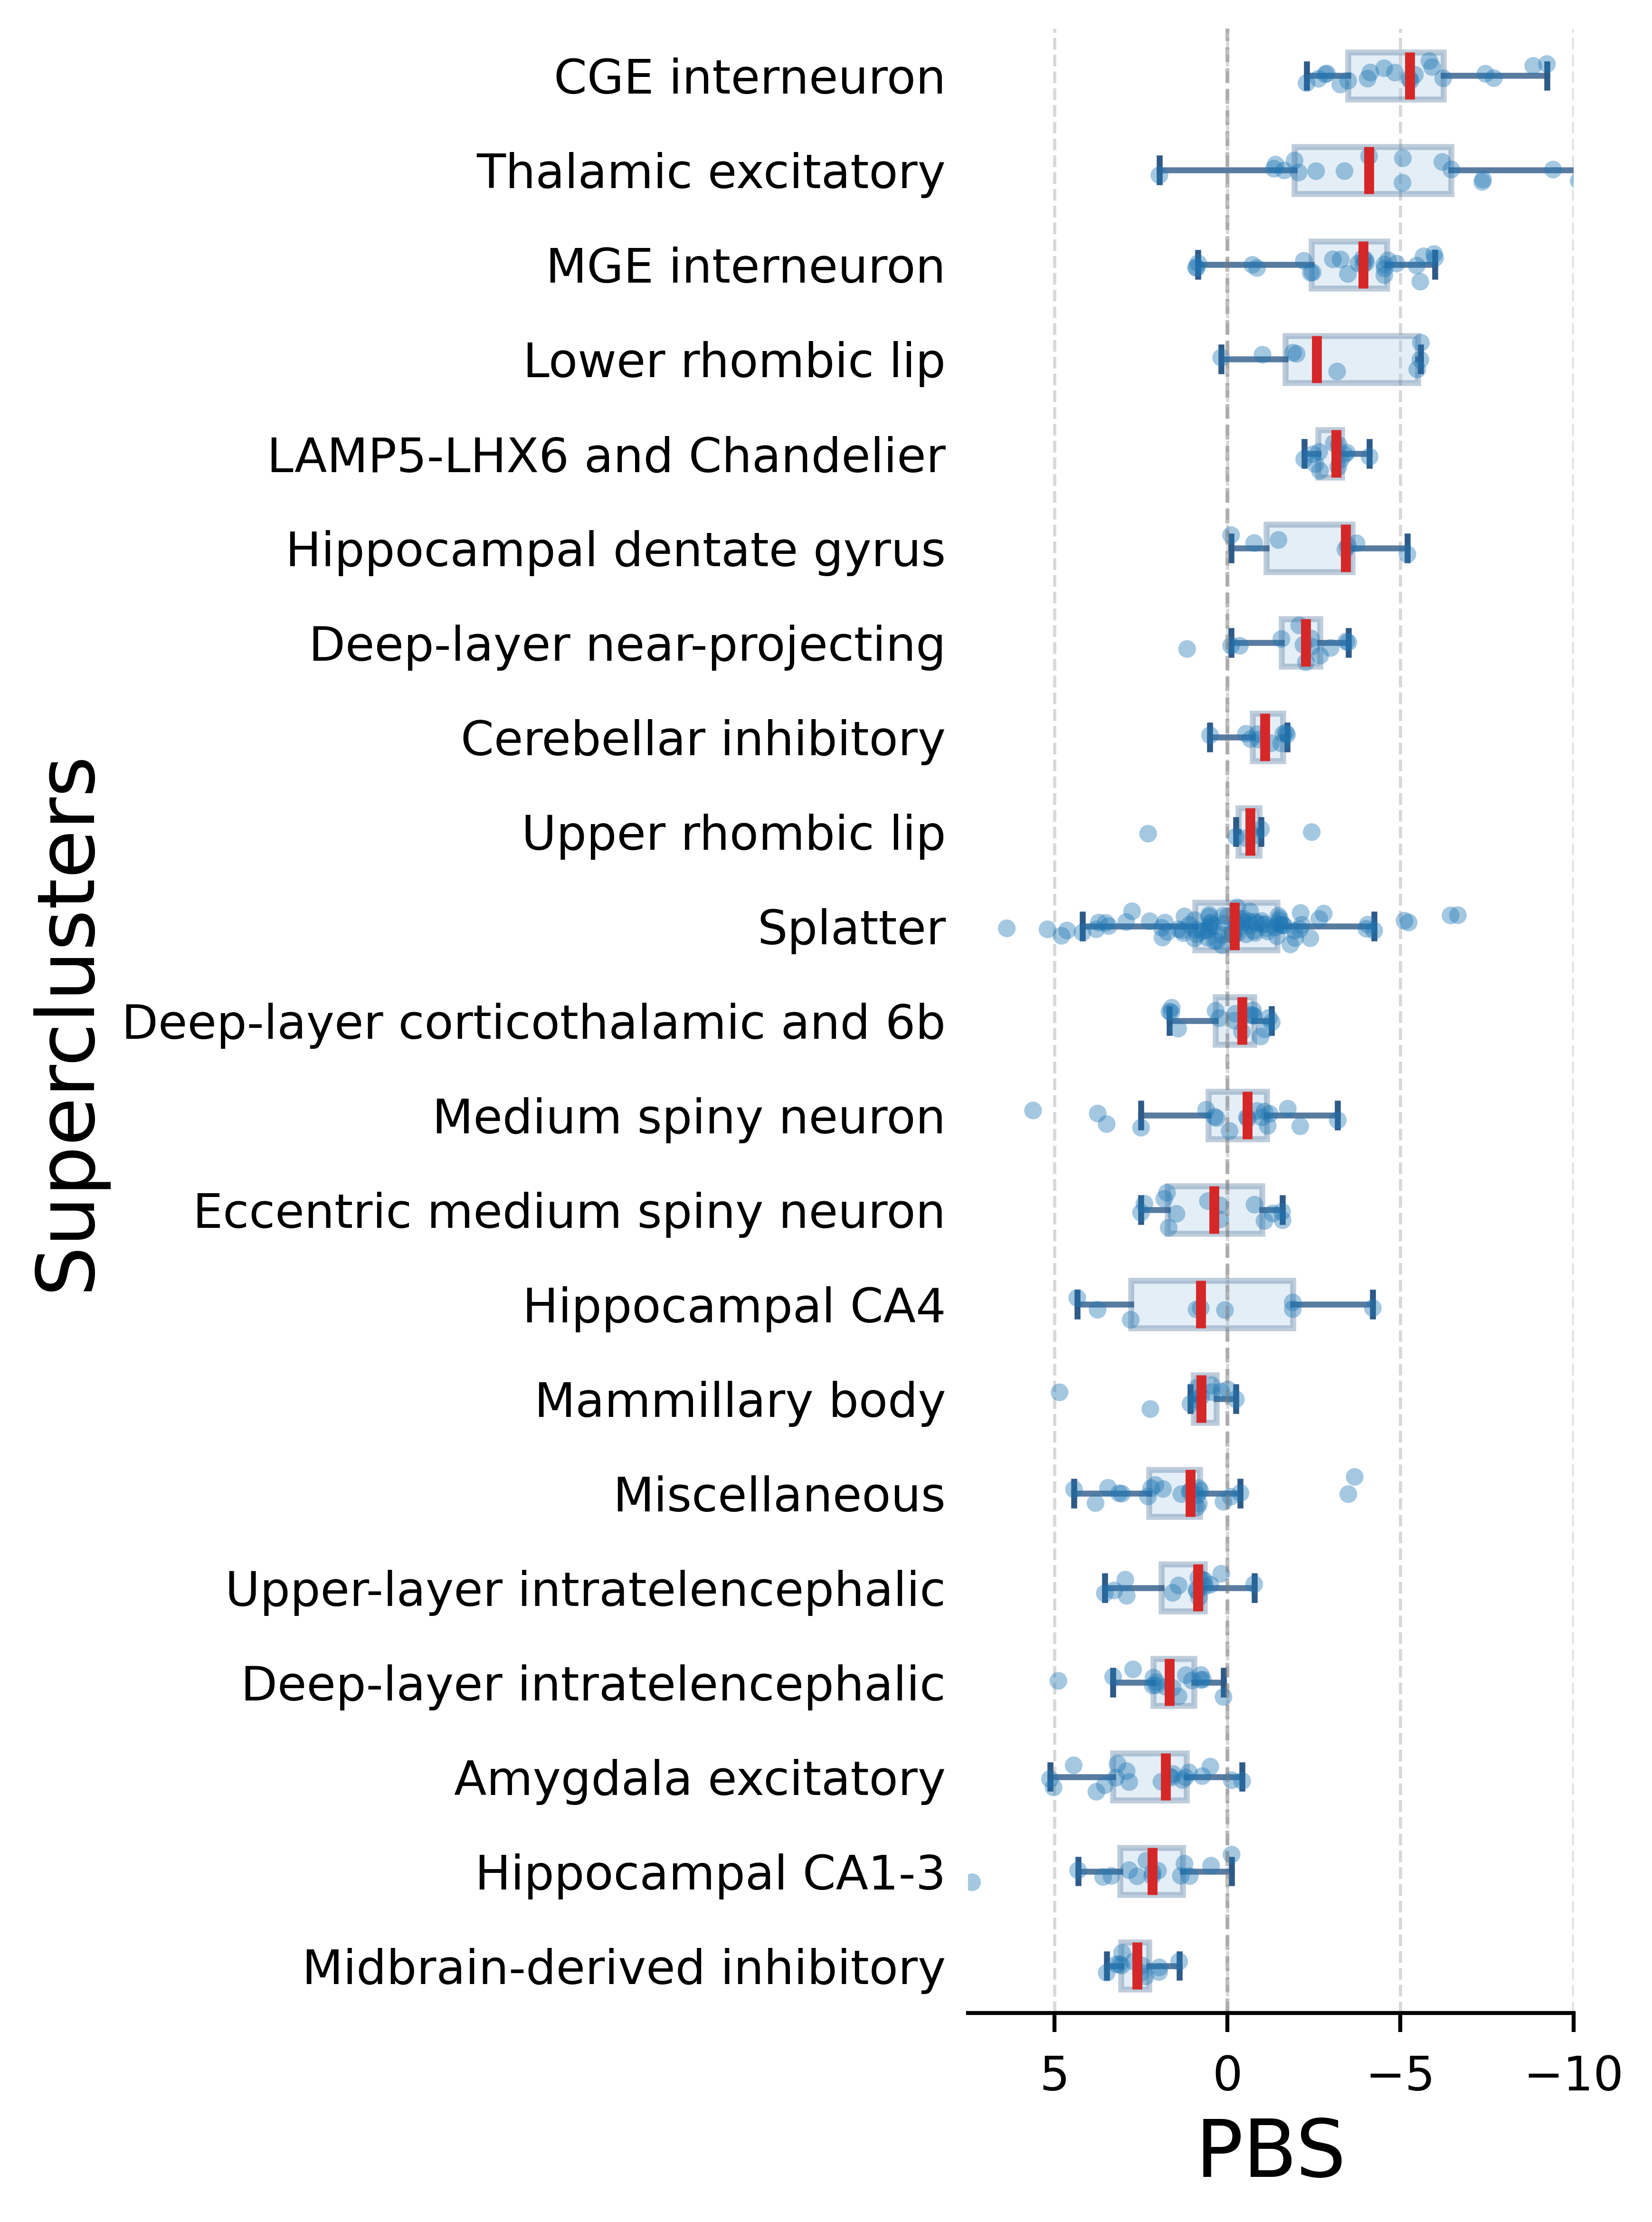

In [136]:
SuperClusterBias_BoxPlot_CorrIQ(HumanCT_res_df_GeneL_Dmis, flip_axis=True, figsize=(6, 8))

In [137]:
Perm_DIR_LGD = "/home/jw3514/Work/CellType_Psy/dat/Pheno_Bias_vs_IQ/IQ_Permuts/HumanCT_Feb25/LGD/"
Perm_DFs_LGD = []

max_count = 100000

i = 0
for df in os.listdir(Perm_DIR_LGD):
    df = pd.read_csv(f"{Perm_DIR_LGD}/{df}", index_col=0)
    df.index = df.index.astype(int)
    Perm_DFs_LGD.append(df)
    i += 1
    if i > max_count:
        break
print(len(Perm_DFs_LGD))

Perm_DIR_Dmis = "/home/jw3514/Work/CellType_Psy/dat/Pheno_Bias_vs_IQ/IQ_Permuts/HumanCT_Feb25/Dmis/"
Perm_DFs_Dmis = []

max_count = 100000

i = 0
for df in os.listdir(Perm_DIR_Dmis):
    df = pd.read_csv(f"{Perm_DIR_Dmis}/{df}", index_col=0)
    df.index = df.index.astype(int)
    Perm_DFs_Dmis.append(df)
    i += 1
    if i > max_count:
        break
print(len(Perm_DFs_Dmis))

10000
10000


In [138]:
HumanCT_res_df_GeneL_LGD

,CT,Supercluster,SpearmanR,SpearmanP,PearsonR,PearsonP,beta,CI_low,CI_high,intercept,r_value,p_value,std_err
266,266,LAMP5-LHX6 and Chandelier,-0.373283,0.006976,-0.309689,0.027003,-7.508829,-14.127316,-0.890341,62.375672,0.095907,0.027003,3.293476
276,276,CGE interneuron,-0.347399,0.012498,-0.279498,0.046998,-6.122169,-12.159847,-0.084490,65.341264,0.078119,0.046998,3.004455
277,277,CGE interneuron,-0.325723,0.019676,-0.285718,0.042110,-6.850552,-13.446873,-0.254231,64.944010,0.081635,0.042110,3.282446
267,267,LAMP5-LHX6 and Chandelier,-0.320927,0.021667,-0.338985,0.014960,-8.272923,-14.864336,-1.681510,63.678145,0.114911,0.014960,3.280003
237,237,Splatter,-0.298844,0.033154,-0.252998,0.073254,-5.933797,-12.447938,0.580344,64.140327,0.064008,0.073254,3.241551
...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,336,Splatter,0.285042,0.042620,0.441108,0.001196,6.546983,2.723013,10.370953,65.316415,0.194576,0.001196,1.902875
342,342,Splatter,0.291332,0.038063,0.309124,0.027298,5.545872,0.647708,10.444035,64.436290,0.095558,0.027298,2.437412
410,410,Splatter,0.301966,0.031275,0.391647,0.004482,8.318418,2.708013,13.928823,64.155217,0.153388,0.004482,2.791836
338,338,Splatter,0.316221,0.023782,0.335270,0.016172,5.070061,0.979983,9.160139,66.376095,0.112406,0.016172,2.035295


In [139]:
results_df_LGD = pd.DataFrame(columns=['Supercluster', 'p_rho', 'p_beta'])

for Supercluster in Neurons:
    ClusterIdx = Anno[Anno["Supercluster"]==Supercluster].index.values
    p_rho_LGD, p_beta_LGD = plot_null_suptercluster_distributions(ClusterIdx, HumanCT_res_df_GeneL_LGD, Perm_DFs_LGD, plot=False)
    
    # Add results to DataFrame
    results_df_LGD = results_df_LGD.append({
        'Supercluster': Supercluster,
        'p_rho': p_rho_LGD,
        'p_beta': p_beta_LGD
    }, ignore_index=True)

/tmp/ipykernel_1084052/1815664614.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df_LGD = results_df_LGD.append({
/tmp/ipykernel_1084052/1815664614.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df_LGD = results_df_LGD.append({
/tmp/ipykernel_1084052/1815664614.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df_LGD = results_df_LGD.append({
/tmp/ipykernel_1084052/1815664614.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df_LGD = results_df_LGD.append({
/tmp/ipykernel_1084052/1815664614.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future

In [140]:
results_df_Dmis = pd.DataFrame(columns=['Supercluster', 'p_rho', 'p_beta'])

for Supercluster in Neurons:
    ClusterIdx = Anno[Anno["Supercluster"]==Supercluster].index.values
    p_rho_Dmis, p_beta_Dmis = plot_null_suptercluster_distributions(ClusterIdx, HumanCT_res_df_GeneL_Dmis, Perm_DFs_Dmis, plot=False)
    
    # Add results to DataFrame
    results_df_Dmis = results_df_Dmis.append({
        'Supercluster': Supercluster,
        'p_rho': p_rho_Dmis,
        'p_beta': p_beta_Dmis
    }, ignore_index=True)

/tmp/ipykernel_1084052/1351866835.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df_Dmis = results_df_Dmis.append({
/tmp/ipykernel_1084052/1351866835.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df_Dmis = results_df_Dmis.append({
/tmp/ipykernel_1084052/1351866835.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df_Dmis = results_df_Dmis.append({
/tmp/ipykernel_1084052/1351866835.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  results_df_Dmis = results_df_Dmis.append({
/tmp/ipykernel_1084052/1351866835.py:8: FutureWarning: The frame.append method is deprecated and will be removed from pandas in 

In [141]:
results_df_LGD

,Supercluster,p_rho,p_beta
0,Amygdala excitatory,0.3107,0.3024
1,CGE interneuron,0.0970,0.0530
2,Cerebellar inhibitory,0.3310,0.2581
3,Deep-layer corticothalamic and 6b,0.2331,0.2343
4,Deep-layer intratelencephalic,0.3710,0.1771
5,Deep-layer near-projecting,0.3955,0.2467
6,Eccentric medium spiny neuron,0.7394,0.8870
7,Hippocampal CA1-3,0.1521,0.0906
8,Hippocampal CA4,0.2419,0.1260
9,Hippocampal dentate gyrus,0.4402,0.4636


In [142]:
results_df_Dmis

,Supercluster,p_rho,p_beta
0,Amygdala excitatory,0.8564,0.8512
1,CGE interneuron,0.0318,0.0199
2,Cerebellar inhibitory,0.4912,0.2723
3,Deep-layer corticothalamic and 6b,0.1102,0.4904
4,Deep-layer intratelencephalic,0.4195,0.8465
5,Deep-layer near-projecting,0.2510,0.3208
6,Eccentric medium spiny neuron,0.5129,0.5461
7,Hippocampal CA1-3,0.9136,0.8122
8,Hippocampal CA4,0.5159,0.5528
9,Hippocampal dentate gyrus,0.1800,0.2472
